# Bug Report Enhancement — tianocore/edk2

Fetches open [`type:bug`](https://github.com/tianocore/edk2/issues?q=is%3Aissue+state%3Aopen+label%3Atype%3Abug) issues (title + full body), sends each to **claude-sonnet-4-6** and produces an enhanced structured record for each open bug.

**Pipeline:** Fetch open issues → LLM enhancement → Structured records → JSON + CSV export

Each enhanced record contains:
- **Structured fields** (verified/corrected from template): bug type, regression status, package, build target, architecture
- **Impact** (LLM inferred): consequences and affected devices/SoCs
- **Three prioritization scores**: bug severity, triaging complexity, component criticality


In [11]:
# Cell 1: Install dependencies
!pip install anthropic requests --quiet
print("Dependencies installed")

Dependencies installed


## Step 1 — API Keys

Keys are loaded from **Colab Secrets** (the key icon in the left sidebar).
Add your secrets there with the toggle enabled for this notebook:

| Secret name | What it is |
|---|---|
| `ANTHROPIC_API_KEY` | Your Anthropic key — https://console.anthropic.com |
| `GITHUB_TOKEN` | GitHub personal access token (optional, raises rate limit from 60 to 5,000 req/hr) — https://github.com/settings/tokens |

> **How to add a secret:** Click the key icon in the left sidebar → *Add new secret* → paste the value → toggle *Notebook access* ON.


In [12]:
# Cell 2: Load API keys from Colab Secrets
import os
from google.colab import userdata

def get_secret(name):
    """Read from Colab Secrets first, fall back to os.environ."""
    try:
        value = userdata.get(name)
        if value:
            return value
    except Exception:
        pass
    return os.environ.get(name, "")

ANTHROPIC_KEY = get_secret("ANTHROPIC_API_KEY")
GITHUB_TOKEN  = get_secret("GITHUB_TOKEN")

print("ANTHROPIC_API_KEY:", "OK (set)" if ANTHROPIC_KEY else "MISSING — add it in Colab Secrets (key icon in sidebar)")
print("GITHUB_TOKEN     :", "OK (set)" if GITHUB_TOKEN  else "not set — unauthenticated (60 req/hr limit)")

if not ANTHROPIC_KEY:
    raise EnvironmentError(
        "ANTHROPIC_API_KEY not found.\n"
        "Go to the key icon in the left sidebar → Add new secret:\n"
        "  Name: ANTHROPIC_API_KEY   Value: sk-ant-...\n"
        "Then toggle 'Notebook access' ON and re-run this cell."
    )

ANTHROPIC_API_KEY: OK (set)
GITHUB_TOKEN     : OK (set)


## Step 2 — Configuration

In [13]:
# Cell 3: Configuration
# @title Configuration { run: "auto" }
GITHUB_REPO  = 'tianocore/edk2'
ISSUE_LABEL  = 'type:bug'
ISSUE_STATE  = 'open'
GITHUB_API   = 'https://api.github.com'
MODEL_NAME   = 'claude-sonnet-4-6'

MAX_ISSUES   = 20    # @param {type:"slider", min:5, max:100, step:5}
AI_DELAY_SEC = 0.5   # @param {type:"number"}
RUN_AI       = True  # @param {type:"boolean"}

# Valid options for structured fields
VALID_BUG_TYPES   = ['Firmware', 'Tool', 'Unit Test']
VALID_REGRESSION  = ['Yes', 'No', 'Not Sure']
VALID_BUILD_TARGET = ['DEBUG', 'RELEASE', 'NOOPT', 'NO-TARGET', 'None']
VALID_ARCHITECTURES = ['IA32', 'X64', 'AARCH64', 'ARM', 'RISCV64', 'LOONGARCH64']
VALID_PACKAGES = [
    'ArmPkg', 'ArmPlatformPkg', 'ArmVirtPkg', 'BaseTools', 'Build or CI Code',
    'CryptoPkg', 'DynamicTablesPkg', 'EmbeddedPkg', 'EmulatorPkg', 'FatPkg',
    'FmpDevicePkg', 'IntelFsp2Pkg', 'IntelFsp2WrapperPkg', 'ManageabilityPkg',
    'MdeModulePkg', 'MdePkg', 'NetworkPkg', 'OvmfPkg', 'PcAtChipsetPkg',
    'PrmPkg', 'RedfishPkg', 'SecurityPkg', 'ShellPkg', 'SourceLevelDebugPkg',
    'StandaloneMmPkg', 'UefiCpuPkg', 'UefiPayloadPkg', 'UnitTestFrameworkPkg', 'Other'
]
VALID_SEVERITY    = ['low', 'medium', 'high', 'critical']
VALID_TRIAGING    = ['simple', 'moderate', 'complex']
VALID_CRITICALITY = ['low', 'medium', 'high']

print(f'Config: model={MODEL_NAME}, {MAX_ISSUES} issues, AI={"on" if RUN_AI else "off"}')
print('Output fields: bug_type, regression, package, component, build_target, architecture, affected_devices, impact, severity, triaging, criticality')

Config: model=claude-sonnet-4-6, 20 issues, AI=on
Output fields: bug_type, regression, package, component, build_target, architecture, affected_devices, impact, severity, triaging, criticality


## Step 3 — Data model

In [14]:
# Cell 4: Data model
import re, json, time
from dataclasses import dataclass, field
from typing import Optional, List

@dataclass
class IssueEnhancement:
    # Raw GitHub fields
    number:         int
    url:            str
    original_title: str
    body:           str
    labels:         list

    # Part A — Structured fields (verified/corrected by LLM)
    bug_type:         list = field(default_factory=list)   # subset of VALID_BUG_TYPES — select all that apply
    regression:       str  = ''    # Yes | No | Not Sure
    package:          list = field(default_factory=list)   # subset of VALID_PACKAGES
    component:        str  = ''    # specific driver/library e.g. NetworkPkg/Dhcp6Dxe
    build_target:     list = field(default_factory=list)   # subset of VALID_BUILD_TARGET — select all that apply
    architecture:     list = field(default_factory=list)   # subset of VALID_ARCHITECTURES
    affected_devices: str  = ''    # affected SoCs/platforms e.g. Ampere Altra, QEMU RISC-V
    impact:           str  = ''    # consequence of the bug — what breaks

    # Part B — Prioritization scores (LLM predicted)
    severity_score:       str = ''   # low | medium | high | critical
    severity_reason:      str = ''
    triaging_score:       str = ''   # simple | moderate | complex
    triaging_reason:      str = ''
    criticality_score:    str = ''   # low | medium | high
    criticality_reason:   str = ''

    # Confidence
    reflective_confidence:        int = 0
    reflective_confidence_reason: str = ''

    ai_error: Optional[str] = None

def prepare_issue(issue):
    return IssueEnhancement(
        number         = issue['number'],
        url            = issue['html_url'],
        original_title = issue['title'].strip(),
        body           = (issue.get('body') or '').strip(),
        labels         = [l['name'] for l in issue.get('labels', [])],
    )

print('Data model defined')

Data model defined


## Step 4 — Fetch open issues from GitHub

In [15]:
# Cell 5: Fetch issues
import requests

def validate_github_token(token):
    if not token:
        return False, "no token provided"
    resp = requests.get(
        f"{GITHUB_API}/user",
        headers={"Accept": "application/vnd.github+json", "Authorization": f"Bearer {token}"},
        timeout=10,
    )
    if resp.status_code == 200:
        return True, resp.json().get("login", "unknown")
    elif resp.status_code == 401:
        return False, "token is invalid or expired (401)"
    else:
        return False, f"unexpected status {resp.status_code}"

def fetch_issues(token, max_issues):
    headers = {"Accept": "application/vnd.github+json"}
    if token:
        headers["Authorization"] = f"Bearer {token}"
    issues, page = [], 1
    per_page = min(100, max_issues)
    while len(issues) < max_issues:
        url = (f"{GITHUB_API}/repos/{GITHUB_REPO}/issues"
               f"?state={ISSUE_STATE}&labels={ISSUE_LABEL}"
               f"&per_page={per_page}&page={page}")
        resp = requests.get(url, headers=headers, timeout=30)
        if resp.status_code == 401:
            raise RuntimeError(
                "GitHub 401 Unauthorized.\n"
                "Your GITHUB_TOKEN is invalid or expired. Fix options:\n"
                "  1. Generate a new token at https://github.com/settings/tokens\n"
                "     (classic token, no scopes needed for public repos)\n"
                "  2. Update the value in Colab Secrets (key icon in sidebar)\n"
                "  3. Or set GITHUB_TOKEN = '' to fetch without auth (60 req/hr limit)"
            )
        if resp.status_code == 403:
            raise RuntimeError("GitHub 403: rate limit hit. Add or refresh your GITHUB_TOKEN.")
        resp.raise_for_status()
        batch = resp.json()
        if not batch: break
        issues.extend(i for i in batch if "pull_request" not in i)
        page += 1
        if len(batch) < per_page: break
    return issues[:max_issues]

token_valid, token_info = validate_github_token(GITHUB_TOKEN)
if GITHUB_TOKEN:
    if token_valid:
        print(f"GitHub token OK — authenticated as: {token_info}")
    else:
        print(f"WARNING: GitHub token check failed — {token_info}")
        print("Continuing without auth (60 req/hr limit)...")
        GITHUB_TOKEN = ""
else:
    print("No GitHub token — fetching unauthenticated (60 req/hr limit)")

print(f"Fetching up to {MAX_ISSUES} open {ISSUE_LABEL!r} issues from {GITHUB_REPO}...")
raw_issues = fetch_issues(GITHUB_TOKEN, MAX_ISSUES)
print(f"Fetched {len(raw_issues)} issues")

Continuing without auth (60 req/hr limit)...
Fetching up to 20 open 'type:bug' issues from tianocore/edk2...
Fetched 20 issues


## Step 5 — Prepare issues

In [16]:
# Cell 6: Prepare issues
results = [prepare_issue(issue) for issue in raw_issues]
print(f'Prepared {len(results)} issues for LLM enhancement')
print(f'Issues with non-empty body: {sum(1 for r in results if r.body)}')

Prepared 20 issues for LLM enhancement
Issues with non-empty body: 20


## Step 6 — LLM Enhancement

Every open issue (title + full body up to 1,500 chars) is sent to **claude-sonnet-4-6** with:
- A structured extraction rubric for Part A fields
- Domain-calibrated criteria for the three prioritization scores
- No RAG — raw issue content only


In [17]:
# Cell 7: LLM enhancement
import anthropic

AI_SYSTEM = """You are an expert edk2/UEFI firmware engineer who reviews open GitHub bug reports.
You have deep knowledge of the tianocore/edk2 codebase, its packages, modules, and conventions.
You produce structured enhancements to help triagers process open issues faster.
Respond ONLY with valid JSON — no markdown, no preamble, no explanation."""

AI_PROMPT_TEMPLATE = """Review this open edk2 GitHub bug report and produce a structured enhancement record.

ORIGINAL TITLE: "__TITLE__"
DESCRIPTION:
__BODY__
LABELS: __LABELS__

---

PART A — STRUCTURED FIELDS
Extract or infer each field from the issue content. Treat any template fields as weak signals only —
verify them against the actual issue text and correct if inconsistent.

bug_type: What type of code does this bug affect? Select all that apply.
  Options: __BUG_TYPES__
  → Return as a JSON array. Example: ["Firmware"] or ["Firmware", "Tool"]
  → If the issue body contradicts the template label, use the body.

regression: Did this work before? Is this a regression?
  Options: __REGRESSION_OPTIONS__
  → Look for phrases like "used to work", "after update", "regression", "worked in previous version".

package: Which EDK II packages are impacted? Select all that apply.
  Options: __PACKAGES__
  → Return as a JSON array. Example: ["NetworkPkg", "MdePkg"]

component: What is the specific driver, library, or module affected within the package?
  → Free text. Be as specific as possible. Use the format Package/ModuleName.
  → Example: "CryptoPkg/TlsLib" or "NetworkPkg/Dhcp6Dxe" or "UefiCpuPkg/ArmCpuDxe"
  → If the specific component cannot be determined, use the package name only.

build_target: Which build targets are affected? Select all that apply.
  Options: __BUILD_TARGETS__
  → Return as a JSON array. Example: ["DEBUG", "RELEASE"] or ["DEBUG", "NOOPT", "RELEASE"]


architecture: Which CPU architectures are affected? Select all that apply.
  Options: __ARCHITECTURES__, Not Sure
  → Return as a JSON array. If unknown, return ["Not Sure"].
  → Example: ["X64", "AARCH64"] or ["Not Sure"]

affected_devices: Which specific hardware platforms, SoCs, or vendors are affected?
  → Free text. List specific device names, SoC families, or vendor platforms mentioned.
  → Example: "Ampere Altra (ADLINK COM-HPC-ALT, ASRock ALTRAD8UD-1L2T)"
  → Example: "QEMU RISC-V rvsp-ref platform"
  → If no specific device is mentioned, write "Not specified".

impact: What is the consequence of this bug? Describe what breaks in one sentence.
  → Focus on the symptom and functional consequence, not the affected device.
  → Example: "TLS handshake fails with security level 3, blocking HTTPS boot on all platforms."

---

PART B — MULTI DIMENSIONAL PRIORITIZATION SCORES

severity_score: How severe or easy to exploit a bug is.
  Options: low | medium | high | critical
  Criteria:
  - critical: remote code execution, data corruption, security vulnerability exploitable in UEFI threat model
  - high:     crash, build failure blocking all configurations, unmitigated security issue
  - medium:   functional bug with workaround, compiler-specific failure, spec compliance gap
  - low:      cosmetic issue, warning, documentation, optional feature, minor code quality

triaging_score: The complexity of a potential patch.
  Options: simple | moderate | complex
  Criteria:
  - simple:   single-file fix, clear root cause, well-understood pattern
  - moderate: multi-file fix or unclear root cause requiring investigation
  - complex:  architectural change, cross-package impact, or deep firmware expertise required

criticality_score: How critical an affected component is.
  Options: low | medium | high
  Criteria:
  - high:   boot-path component, security-sensitive module (CryptoPkg, NetworkPkg, SecurityPkg, MdePkg core)
  - medium: platform-specific or optional component used by multiple vendors
  - low:    tooling, emulator, optional package, or documentation

reflective_confidence (0-100): How confident are you in the overall enhancement?
  - 90-100: issue was well-described; all fields could be reliably determined
  - 70-89:  most fields reliable; one or two required inference from limited context
  - 50-69:  several fields uncertain; description was sparse or ambiguous
  - 20-49:  most fields are guesses; description provided very little diagnostic information
  - 0-19:   description was empty or useless; enhancement has high uncertainty

---

Respond ONLY with this JSON:
{
  "bug_type": ["<type1>", "<type2>"],
  "regression":           "<one of the regression options>",
  "package":              ["<pkg1>", "<pkg2>"],
  "component":            "<specific driver/library e.g. CryptoPkg/TlsLib>",
  "build_target": ["<target1>", "<target2>"],
  "architecture":         ["<arch1>", "<arch2>"],
  "affected_devices":     "<specific hardware platforms or Not specified>",
  "impact":               "<one sentence describing the functional consequence>",
  "severity_score":       "<low|medium|high|critical>",
  "severity_reason":      "<one sentence justifying severity>",
  "triaging_score":       "<simple|moderate|complex>",
  "triaging_reason":      "<one sentence justifying triaging complexity>",
  "criticality_score":    "<low|medium|high>",
  "criticality_reason":   "<one sentence justifying component criticality>",
  "reflective_confidence": <0-100>,
  "reflective_confidence_reason": "<one sentence: how confident are you in this enhancement overall>"
}"""

def build_prompt(analysis):
    body_text = analysis.body[:1500] if analysis.body else '(no description provided)'
    return (AI_PROMPT_TEMPLATE
        .replace('__TITLE__',              analysis.original_title)
        .replace('__BODY__',               body_text)
        .replace('__LABELS__',             ', '.join(analysis.labels) if analysis.labels else 'none')
        .replace('__BUG_TYPES__',          ' | '.join(VALID_BUG_TYPES))
        .replace('__REGRESSION_OPTIONS__', ' | '.join(VALID_REGRESSION))
        .replace('__PACKAGES__',           ' | '.join(VALID_PACKAGES))
        .replace('__BUILD_TARGETS__',      ' | '.join(VALID_BUILD_TARGET))
        .replace('__ARCHITECTURES__',      ' | '.join(VALID_ARCHITECTURES))
    )

def run_ai_enhancement(analysis, client):
    prompt = build_prompt(analysis)
    try:
        msg = client.messages.create(
            model       = MODEL_NAME,
            max_tokens  = 1400,
            temperature = 0,
            system      = AI_SYSTEM,
            messages    = [{'role': 'user', 'content': prompt}],
        )
        raw    = msg.content[0].text.strip()
        raw    = re.sub(r'^```(?:json)?|```$', '', raw, flags=re.MULTILINE).strip()
        parsed = json.loads(raw)

        analysis.bug_type = parsed.get('bug_type', [])
        analysis.regression           = parsed.get('regression', '')
        analysis.package              = parsed.get('package', [])
        analysis.component            = parsed.get('component', '')
        analysis.build_target = parsed.get('build_target', [])
        analysis.architecture         = parsed.get('architecture', [])
        analysis.affected_devices     = parsed.get('affected_devices', '')
        analysis.impact               = parsed.get('impact', '')
        analysis.severity_score       = parsed.get('severity_score', '')
        analysis.severity_reason      = parsed.get('severity_reason', '')
        analysis.triaging_score       = parsed.get('triaging_score', '')
        analysis.triaging_reason      = parsed.get('triaging_reason', '')
        analysis.criticality_score    = parsed.get('criticality_score', '')
        analysis.criticality_reason   = parsed.get('criticality_reason', '')
        analysis.reflective_confidence        = int(parsed.get('reflective_confidence', 0))
        analysis.reflective_confidence_reason = parsed.get('reflective_confidence_reason', '')

    except Exception as exc:
        analysis.ai_error = str(exc)

if not RUN_AI:
    print('AI skipped (RUN_AI=False)')
elif not ANTHROPIC_KEY:
    print('No Anthropic key - skipping AI')
else:
    client = anthropic.Anthropic(api_key=ANTHROPIC_KEY)
    print(f'Running LLM enhancement on {len(results)} issues using {MODEL_NAME}...')
    for idx, analysis in enumerate(results, 1):
        print(f'  [{idx:>3}/{len(results)}] #{analysis.number}: {analysis.original_title[:60]}...')
        run_ai_enhancement(analysis, client)
        if idx < len(results):
            time.sleep(AI_DELAY_SEC)
    ai_ok  = sum(1 for r in results if r.severity_score)
    ai_err = sum(1 for r in results if r.ai_error)
    avg_rc = sum(r.reflective_confidence for r in results if r.severity_score) / ai_ok if ai_ok else 0
    sev_counts = {s: sum(1 for r in results if r.severity_score == s) for s in VALID_SEVERITY}
    tri_counts = {t: sum(1 for r in results if r.triaging_score == t) for t in VALID_TRIAGING}
    print(f'Done: {ai_ok} enhanced, {ai_err} errors')
    print(f'Avg reflective confidence : {avg_rc:.0f}/100')
    print(f'Severity distribution     : {sev_counts}')
    print(f'Triaging distribution     : {tri_counts}')

Running LLM enhancement on 20 issues using claude-sonnet-4-6...
  [  1/20] #12766: [Bug]: Row/column arguments in Console Out are transposed...
  [  2/20] #12708: [Bug]: Incompatible change at UEFI 2.11 type field at ARM Pr...
  [  3/20] #12693: [Bug]: ManageabilityPkg CLANGDWARF CI failure (BaseManageabi...
  [  4/20] #12680: [Bug]: ECC not generate enough 5 fields in UefiCpuPkg/Librar...
  [  5/20] #12675: [Bug]: Commit a9c9cfa0790c3fce6957db603488b85306c37385 cause...
  [  6/20] #12651: [Bug]: Booting netboot.xyz over HTTPS fails with "EE certifi...
  [  7/20] #12646: [Bug]: ArmStandaloneMmCoreEntryPoint DelegatedEventLoop infi...
  [  8/20] #12644: [Bug]: Discover Nvme Namespaces function is called multiple ...
  [  9/20] #12617: [Bug]: FWTS Authenticated variable test fails...
  [ 10/20] #12588: [Bug]: HDMI ports need changed during boot process...
  [ 11/20] #12587: [Bug]: TPM table offset to LAML and LASL are incorrect...
  [ 12/20] #12566: [Bug]: Allocator: Some Logic Checks th

## Step 7 — Per-issue results

In [18]:
# Cell 8: Render per-issue results
from IPython.display import display, HTML

def score_badge(label, value, color):
    return f"<span style='background:{color};color:#fff;padding:2px 8px;border-radius:4px;font-size:12px;font-weight:600'>{label}: {value}</span>"

def severity_color(s):
    return {'critical': '#8e1a1a', 'high': '#c0392b', 'medium': '#d4860a', 'low': '#2d9e6b'}.get(s, '#888')

def triaging_color(t):
    return {'complex': '#8e44ad', 'moderate': '#185fa5', 'simple': '#2d9e6b'}.get(t, '#888')

def criticality_color(c):
    return {'high': '#c0392b', 'medium': '#d4860a', 'low': '#2d9e6b'}.get(c, '#888')

def confidence_color(s):
    if s >= 75: return '#185fa5'
    if s >= 50: return '#8e44ad'
    return '#555'

def render_issue(a, idx, total):
    if a.ai_error:
        ai_block = f"<div style='color:#c0392b;font-size:13px;margin-top:8px'>AI error: {a.ai_error}</div>"
    elif a.severity_score:
        ai_block = f"""
        <div style='margin-top:10px;padding:10px 14px;background:#f8f9ff;border-left:3px solid #4a6cf7;border-radius:0 6px 6px 0'>
          <div style='display:flex;align-items:center;gap:8px;margin-bottom:10px;flex-wrap:wrap'>
            <span style='font-size:13px;font-weight:600'>Enhancement</span>
            {score_badge('Severity', a.severity_score, severity_color(a.severity_score))}
            {score_badge('Triaging', a.triaging_score, triaging_color(a.triaging_score))}
            {score_badge('Criticality', a.criticality_score, criticality_color(a.criticality_score))}
            {score_badge('Confidence', f'{a.reflective_confidence}/100', confidence_color(a.reflective_confidence))}
          </div>
          <div style='display:grid;grid-template-columns:1fr 1fr;gap:8px;margin-bottom:8px'>
            <div>
              <p style='font-size:12px;font-weight:600;margin:0 0 2px'>Structured fields</p>
              <table style='font-size:12px;color:#444;border-collapse:collapse;width:100%'>
                <tr><td style='padding:1px 6px 1px 0;color:#888'>Bug type</td><td>{a.bug_type}</td></tr>
                <tr><td style='padding:1px 6px 1px 0;color:#888'>Regression</td><td>{a.regression}</td></tr>
                <tr><td style='padding:1px 6px 1px 0;color:#888'>Package</td><td>{a.package}</td></tr>
                <tr><td style='padding:1px 6px 1px 0;color:#888'>Build target</td><td>{a.build_target}</td></tr>
                <tr><td style='padding:1px 6px 1px 0;color:#888'>Architecture</td><td>{a.architecture}</td></tr>
              </table>
            </div>
            <div>
              <p style='font-size:12px;font-weight:600;margin:0 0 2px'>Impact (inferred)</p>
              <p style='font-size:12px;color:#444;margin:0 0 8px'>{a.impact}</p>
              <p style='font-size:12px;font-weight:600;margin:0 0 2px'>Score rationale</p>
              <p style='font-size:12px;color:#444;margin:0'>Severity: {a.severity_reason}</p>
              <p style='font-size:12px;color:#444;margin:0'>Triaging: {a.triaging_reason}</p>
              <p style='font-size:12px;color:#444;margin:0'>Criticality: {a.criticality_reason}</p>
            </div>
          </div>
          <p style='font-size:12px;color:#666;margin:0'><b>Confidence:</b> {a.reflective_confidence_reason}</p>
        </div>"""
    else:
        ai_block = "<div style='color:#888;font-size:13px;margin-top:8px'>AI not run</div>"

    labels_html = ' '.join(
        f"<span style='background:#eef;color:#44a;font-size:11px;padding:1px 6px;border-radius:3px'>{l}</span>"
        for l in a.labels
    )

    return f"""<div style='border:1px solid #e0e0e0;border-radius:8px;padding:14px 18px;margin-bottom:12px;background:#fff'>
  <div style='display:flex;justify-content:space-between;align-items:flex-start;margin-bottom:6px'>
    <span style='font-size:12px;color:#888'>#{a.number} &nbsp; {idx}/{total}</span>
    <div style='display:flex;flex-wrap:wrap;gap:4px'>{labels_html}</div>
  </div>
  <p style='margin:0 0 2px;font-size:14px;font-weight:600;color:#333'>{a.original_title}</p>
  <a href='{a.url}' target='_blank' style='font-size:12px;color:#4a6cf7'>{a.url}</a>
  {ai_block}
</div>"""

for i, a in enumerate(results):
    display(HTML(render_issue(a, i+1, len(results))))

Bug type,['Firmware']
Regression,Not Sure
Package,['EmulatorPkg']
Build target,['NO-TARGET']
Architecture,"['IA32', 'X64']"


Bug type,['Firmware']
Regression,Yes
Package,['UefiCpuPkg']
Build target,"['DEBUG', 'RELEASE', 'NOOPT']"
Architecture,"['AARCH64', 'ARM']"


Bug type,['Firmware']
Regression,Not Sure
Package,['ManageabilityPkg']
Build target,"['DEBUG', 'RELEASE']"
Architecture,['X64']


Bug type,['Tool']
Regression,Not Sure
Package,"['UefiCpuPkg', 'Build or CI Code']"
Build target,['NO-TARGET']
Architecture,['RISCV64']


Bug type,['Firmware']
Regression,Yes
Package,['ArmPkg']
Build target,"['DEBUG', 'RELEASE', 'NOOPT', 'NO-TARGET']"
Architecture,['AARCH64']


...

Bug type,['Firmware']
Regression,Not Sure
Package,['NetworkPkg']
Build target,"['DEBUG', 'RELEASE']"
Architecture,['Not Sure']


Bug type,['Firmware']
Regression,Not Sure
Package,['UefiCpuPkg']
Build target,['NO-TARGET']
Architecture,['X64']


Bug type,['Tool']
Regression,Yes
Package,['BaseTools']
Build target,"['DEBUG', 'RELEASE', 'NOOPT']"
Architecture,['Not Sure']


Bug type,['Firmware']
Regression,No
Package,"['OvmfPkg', 'UefiCpuPkg']"
Build target,['NO-TARGET']
Architecture,"['X64', 'IA32']"


Bug type,['Tool']
Regression,Not Sure
Package,['Build or CI Code']
Build target,['None']
Architecture,['Not Sure']


## Step 8 — Summary dashboard

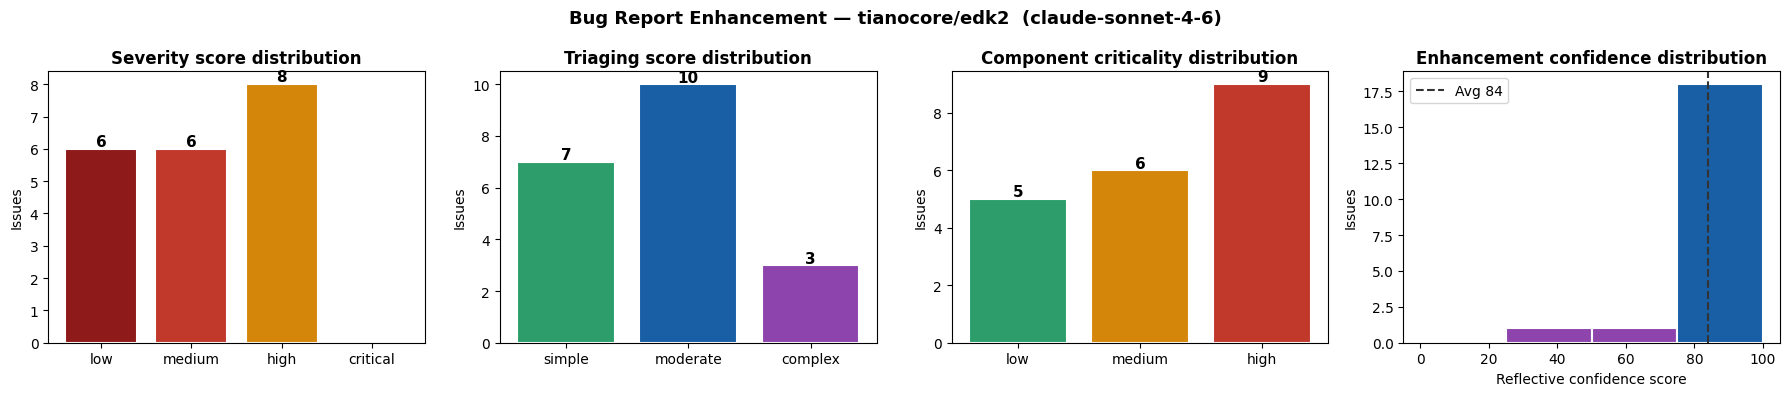

Issues processed          : 20
Successfully enhanced     : 20
Avg reflective confidence : 84/100
Severity distribution     : {'low': 6, 'medium': 6, 'high': 8, 'critical': 0}
Triaging distribution     : {'simple': 7, 'moderate': 10, 'complex': 3}
Criticality distribution  : {'low': 5, 'medium': 6, 'high': 9}


In [19]:
# Cell 9: Summary dashboard
import matplotlib.pyplot as plt
import numpy as np

enhanced = [r for r in results if r.severity_score]
rc_scores = [r.reflective_confidence for r in enhanced]
total     = len(results)
avg_rc    = sum(rc_scores) / len(rc_scores) if rc_scores else 0

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle(f'Bug Report Enhancement — tianocore/edk2  ({MODEL_NAME})', fontsize=13, fontweight='bold')

# Severity distribution
sev_vals   = [r.severity_score for r in enhanced]
sev_labels = VALID_SEVERITY
sev_counts = [sev_vals.count(s) for s in sev_labels]
sev_colors = ['#8e1a1a', '#c0392b', '#d4860a', '#2d9e6b']
axes[0].bar(sev_labels, sev_counts, color=sev_colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Severity score distribution', fontweight='bold')
axes[0].set_ylabel('Issues')
for i, v in enumerate(sev_counts):
    if v > 0: axes[0].text(i, v + 0.1, str(v), ha='center', fontsize=11, fontweight='bold')

# Triaging distribution
tri_vals   = [r.triaging_score for r in enhanced]
tri_labels = VALID_TRIAGING
tri_counts = [tri_vals.count(t) for t in tri_labels]
tri_colors = ['#2d9e6b', '#185fa5', '#8e44ad']
axes[1].bar(tri_labels, tri_counts, color=tri_colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('Triaging score distribution', fontweight='bold')
axes[1].set_ylabel('Issues')
for i, v in enumerate(tri_counts):
    if v > 0: axes[1].text(i, v + 0.1, str(v), ha='center', fontsize=11, fontweight='bold')

# Criticality distribution
crit_vals   = [r.criticality_score for r in enhanced]
crit_labels = VALID_CRITICALITY
crit_counts = [crit_vals.count(c) for c in crit_labels]
crit_colors = ['#2d9e6b', '#d4860a', '#c0392b']
axes[2].bar(crit_labels, crit_counts, color=crit_colors, edgecolor='white', linewidth=1.5)
axes[2].set_title('Component criticality distribution', fontweight='bold')
axes[2].set_ylabel('Issues')
for i, v in enumerate(crit_counts):
    if v > 0: axes[2].text(i, v + 0.1, str(v), ha='center', fontsize=11, fontweight='bold')

# Reflective confidence histogram
n, edges, patches = axes[3].hist(rc_scores, bins=[0,25,50,75,100], edgecolor='white', linewidth=1.5)
for patch, color in zip(patches, ['#555','#8e44ad','#8e44ad','#185fa5']):
    patch.set_facecolor(color)
axes[3].axvline(avg_rc, color='#333', linestyle='--', linewidth=1.5, label=f'Avg {avg_rc:.0f}')
axes[3].set_xlabel('Reflective confidence score')
axes[3].set_ylabel('Issues')
axes[3].set_title('Enhancement confidence distribution', fontweight='bold')
axes[3].legend(fontsize=10)

plt.tight_layout()
plt.savefig('bug_enhancement_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Issues processed          : {total}')
print(f'Successfully enhanced     : {len(enhanced)}')
print(f'Avg reflective confidence : {avg_rc:.0f}/100')
print(f'Severity distribution     : { {s: sev_counts[i] for i,s in enumerate(sev_labels)} }')
print(f'Triaging distribution     : { {t: tri_counts[i] for i,t in enumerate(tri_labels)} }')
print(f'Criticality distribution  : { {c: crit_counts[i] for i,c in enumerate(crit_labels)} }')

## Step 9 — Export JSON + CSV

In [20]:
# Cell 10: Export JSON + CSV and download
import json, csv
from google.colab import files

# JSON
report = [{
    'number':                        a.number,
    'url':                           a.url,
    'labels':                        a.labels,
    'original_title':                a.original_title,
    'bug_type':                      a.bug_type,
    'regression':                    a.regression,
    'package':                       a.package,
    'build_target':                  a.build_target,
    'architecture':                  a.architecture,
    'component':        a.component,
'affected_devices': a.affected_devices,
    'impact':                        a.impact,
    'severity_score':                a.severity_score,
    'severity_reason':               a.severity_reason,
    'triaging_score':                a.triaging_score,
    'triaging_reason':               a.triaging_reason,
    'criticality_score':             a.criticality_score,
    'criticality_reason':            a.criticality_reason,
    'reflective_confidence':         a.reflective_confidence,
    'reflective_confidence_reason':  a.reflective_confidence_reason,
    'ai_error':                      a.ai_error,
} for a in results]

with open('bug_enhancement_report.json', 'w', encoding='utf-8') as f:
    json.dump(report, f, indent=2, ensure_ascii=False)
print('Saved: bug_enhancement_report.json')

# CSV
CSV_FIELDS = [
    'number', 'url', 'labels', 'original_title',
    'bug_type', 'regression', 'package', 'build_target', 'architecture', 'component', 'affected_devices','impact',
    'severity_score', 'severity_reason',
    'triaging_score', 'triaging_reason',
    'criticality_score', 'criticality_reason',
    'reflective_confidence', 'reflective_confidence_reason',
    'ai_error',
]

with open('bug_enhancement_report.csv', 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=CSV_FIELDS)
    writer.writeheader()
    for a in results:
        writer.writerow({
            'number':                       a.number,
            'url':                          a.url,
            'labels':                       ' | '.join(a.labels),
            'original_title':               a.original_title,
            'bug_type': ' | '.join(a.bug_type) if isinstance(a.bug_type, list) else a.bug_type,
            'regression':                   a.regression,
            'package':                      a.package,
            'build_target': ' | '.join(a.build_target) if isinstance(a.build_target, list) else a.build_target,
            'architecture':                 a.architecture,
            'component':        a.component,
'affected_devices': a.affected_devices,
            'impact':                       a.impact,
            'severity_score':               a.severity_score,
            'severity_reason':              a.severity_reason,
            'triaging_score':               a.triaging_score,
            'triaging_reason':              a.triaging_reason,
            'criticality_score':            a.criticality_score,
            'criticality_reason':           a.criticality_reason,
            'reflective_confidence':        a.reflective_confidence,
            'reflective_confidence_reason': a.reflective_confidence_reason,
            'ai_error':                     a.ai_error,
        })
print('Saved: bug_enhancement_report.csv')

files.download('bug_enhancement_report.json')
files.download('bug_enhancement_report.csv')
print('Downloads triggered')

Saved: bug_enhancement_report.json
Saved: bug_enhancement_report.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloads triggered
